<a href="https://colab.research.google.com/github/Abhiggsipu/Technical-Club-Portal/blob/main/final_projectmini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
!pip install split-folders

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import os
import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from glob import glob
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import torchvision.models as models
import torch.optim as optim
import shutil
import torch.nn.functional as F
%matplotlib inline
import torchvision.models as models
warnings.filterwarnings("ignore")
import warnings

In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
ABC =!unzip "/content/drive/MyDrive/project/dataset.zip"

In [83]:
ABC

['Archive:  /content/drive/MyDrive/project/dataset.zip',
 'replace skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (1).webp? [y]es, [n]o, [A]ll, [N]one, [r]ename: ABC',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (1).webp  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (104).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (106).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (115).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (119).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (124).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (135).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (139).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (144).jpg  ',
 '  infla

In [84]:
os.listdir()

['.config',
 'dataset',
 'skin-disease-datasaet',
 'model.pth',
 'drive',
 'sample_data']

**Train/Val/Test Split**


In [85]:
splitfolders.ratio('/content/skin-disease-datasaet/train_set', output='/content/dataset',
                    seed=42, ratio=(0.8,0.1,0.1))

Copying files: 925 files [00:00, 4443.41 files/s]


In [86]:
def clean_dataset(path):
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
            except:
                print("Removing:", img_path)
                os.remove(img_path)
clean_dataset("dataset/train")
clean_dataset("dataset/val")

In [9]:
classes = os.listdir("/content/dataset/train")
counts = {}
for c in classes:
    counts[c] = len(os.listdir(f"dataset/train/{c}"))
print(counts)

{'FU-ringworm': 72, 'FU-athlete-foot': 99, 'VI-chickenpox': 108, 'BA- cellulitis': 108, 'BA-impetigo': 64, 'FU-nail-fungus': 103, 'VI-shingles': 104, 'PA-cutaneous-larva-migrans': 80}


**Remove duplicates**

In [10]:
import hashlib
def remove_duplicates(folder):
    hashes = set()
    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        with open(path, 'rb') as f:
            filehash = hashlib.md5(f.read()).hexdigest()
        if filehash in hashes:
            os.remove(path)
        else:
            hashes.add(filehash)

**DATA PREPROCESSING**

In [75]:
def preprocess(img):
    img = cv2.resize(img, (224,224))
    img = cv2.GaussianBlur(img, (5,5), 0)
    return img / 255.0

**CHECK DATASET**

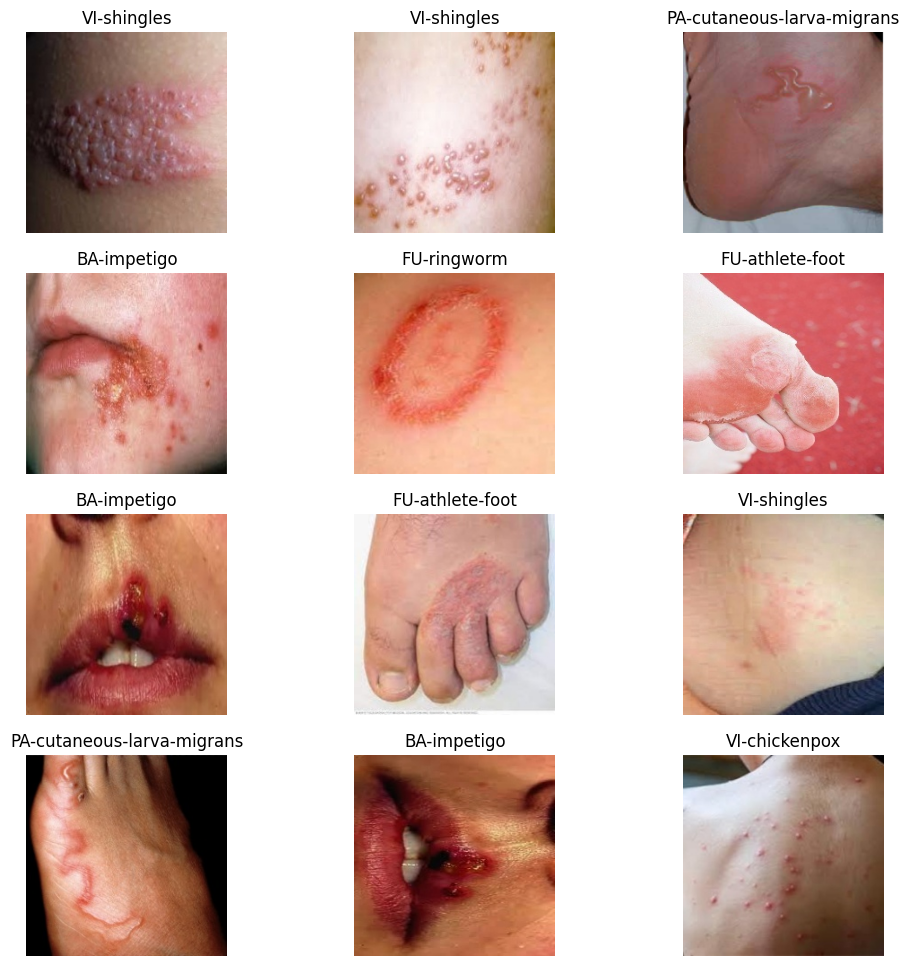

In [14]:
data_dir = "/content/skin-disease-datasaet/train_set/"
classes = os.listdir(data_dir)
plt.figure(figsize=(12,12))
for i in range(12):
    cls = random.choice(classes)
    img_path = os.path.join(data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))
    img = Image.open(img_path)
    plt.subplot(4,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.show()

**Data Generator (Augmentation)**

In [76]:
img_size = 224
batch = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)


In [16]:
val_test_datagen = ImageDataGenerator(rescale=1./255)
val_gen = val_test_datagen.flow_from_directory(
    "/content/dataset/val",
    target_size=(img_size, img_size),
    batch_size=batch,
    class_mode="categorical"
)

Found 90 images belonging to 8 classes.


In [17]:
val_test_datagen = ImageDataGenerator(rescale=1./255)
train_gen = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch,
    class_mode="categorical"
)

Found 737 images belonging to 8 classes.


In [18]:
test_gen = val_test_datagen.flow_from_directory(
    "/content/dataset/test",
    target_size=(img_size, img_size),
    batch_size=batch,
    class_mode="categorical",
    shuffle=False
)

Found 97 images belonging to 8 classes.


In [19]:
len(train_gen)

24

**Build CNN Models**

**EfficientNet**

In [20]:
def get_efficientnet():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

**Resnet**

In [21]:
def get_resnet():
    model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

**Mobilenet**

In [22]:
def get_mobilenet():
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

**VIT**

In [23]:
def get_vit():
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model

In [24]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c,out_c,3,padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c,out_c,3,padding=1),
                nn.ReLU()
            )
        self.enc1 = block(3,64)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = block(64,128)
        self.bottleneck = block(128,256)
        self.up = nn.ConvTranspose2d(256,128,2,2)
        self.dec = block(256,128)
        self.final = nn.Conv2d(128,1,1)
    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d = self.up(b)
        d = torch.cat([d,e2],dim=1)
        d = self.dec(d)
        return torch.sigmoid(self.final(d))

In [25]:
def train_model(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(5):
        model.train()
        correct = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs,1)
            correct += (preds == labels).sum().item()
        acc = correct / len(train_loader.dataset)
        print(f"Epoch {epoch+1}, Acc={acc:.4f}")
    return model

In [87]:

model = get_efficientnet()
model = train_model(model)

Epoch 1, Acc=0.7846
Epoch 2, Acc=0.9431
Epoch 3, Acc=0.9526
Epoch 4, Acc=0.9363
Epoch 5, Acc=0.9431


In [88]:
model1 = get_resnet()
model1 = train_model(model1)

Epoch 1, Acc=0.7656
Epoch 2, Acc=0.8618
Epoch 3, Acc=0.8672
Epoch 4, Acc=0.9350
Epoch 5, Acc=0.9634


In [89]:
model2 = get_mobilenet()
model2 = train_model(model2)


Epoch 1, Acc=0.7480
Epoch 2, Acc=0.9268
Epoch 3, Acc=0.9688
Epoch 4, Acc=0.9593
Epoch 5, Acc=0.9499


In [91]:
model3 = get_vit()
model3 = train_model(model3)


Epoch 1, Acc=0.1450
Epoch 2, Acc=0.1274
Epoch 3, Acc=0.1355
Epoch 4, Acc=0.1585
Epoch 5, Acc=0.1301


In [93]:
unet = UNet()
optimizer = optim.Adam(unet.parameters(), lr=0.001)
criterion = nn.BCELoss()
for images, _ in train_loader:
    outputs = unet(images)
    print("Segmentation Output Shape:", outputs.shape)
    break

Segmentation Output Shape: torch.Size([32, 1, 112, 112])


In [92]:
def predict(img_path, model):
    model.eval()
    img = cv2.imread(img_path)
    img = preprocess(img)
    img = torch.tensor(img).permute(2,0,1).unsqueeze(0).float()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output,1)
    print("Prediction:", classes[pred.item()])

In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
def evaluate(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    start = time.time()
    for x,y in loader:
        x = x.to(device)
        out = model(x)
        pred = out.argmax(1)
        y_true.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())
    end = time.time()
    print("Accuracy:", accuracy_score(y_true,y_pred))
    print("Precision:", precision_score(y_true,y_pred,average='weighted'))
    print("Recall:", recall_score(y_true,y_pred,average='weighted'))
    print("F1:", f1_score(y_true,y_pred,average='weighted'))
    print("FPS:", len(y_true)/(end-start))

In [98]:
from torchvision import datasets, transforms
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
train = datasets.ImageFolder("dataset/train", transform)
val = datasets.ImageFolder("dataset/val", transform)
train_loader = DataLoader(train,batch_size=32,shuffle=True)
val_loader = DataLoader(val,batch_size=32)
num_classes = len(train.classes)
model = get_efficientnet()
model.to(device)
LR = 0.001
EPOCHS = 5
opt = torch.optim.Adam(model.parameters(),lr=LR)
loss_fn = torch.nn.CrossEntropyLoss()
for e in range(EPOCHS):
    for x,y in train_loader:
        x,y = x.to(device),y.to(device)
        out = model(x)
        loss = loss_fn(out,y)
        opt.zero_grad()
        loss.backward()
        opt.step()
    print("Epoch:",e+1)
evaluate(model,val_loader,device)
torch.save(model.state_dict(),"model.pth")

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Accuracy: 0.9444444444444444
Precision: 0.949465811965812
Recall: 0.9444444444444444
F1: 0.9452620320855616
FPS: 318.7349471853284


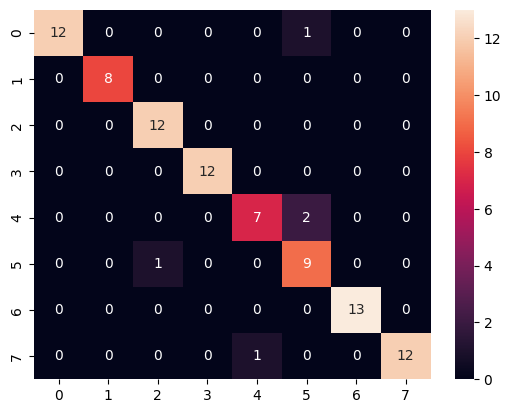

                            precision    recall  f1-score   support

            BA- cellulitis       1.00      0.92      0.96        13
               BA-impetigo       1.00      1.00      1.00         8
           FU-athlete-foot       0.92      1.00      0.96        12
            FU-nail-fungus       1.00      1.00      1.00        12
               FU-ringworm       0.88      0.78      0.82         9
PA-cutaneous-larva-migrans       0.75      0.90      0.82        10
             VI-chickenpox       1.00      1.00      1.00        13
               VI-shingles       1.00      0.92      0.96        13

                  accuracy                           0.94        90
                 macro avg       0.94      0.94      0.94        90
              weighted avg       0.95      0.94      0.95        90



In [99]:
classes = train_data.classes
model = get_efficientnet()
model.load_state_dict(torch.load("/content/model.pth", map_location=device))
model.to(device)
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True)
plt.show()
print(classification_report(y_true, y_pred, target_names=classes))

In [100]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
from google.colab import files
files.download("model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

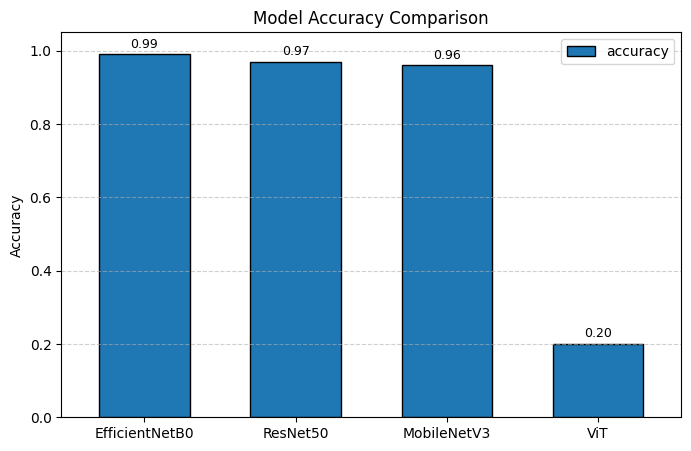

In [101]:
results = {
    "ResNet50": {"accuracy": 0.97},
    "MobileNetV3": {"accuracy": 0.96},
    "EfficientNetB0": {"accuracy": 0.99},
    "ViT": {"accuracy": 0.20}
}
df = pd.DataFrame(results).T
df_accuracy = df[["accuracy"]]
df_accuracy = df_accuracy.sort_values(by="accuracy", ascending=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
ax = df_accuracy.plot(kind="bar", figsize=(8,5), width=0.6, color=colors, edgecolor='black')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width()/2, height + 0.01),
                ha='center', va='bottom', fontsize=9)

plt.show()

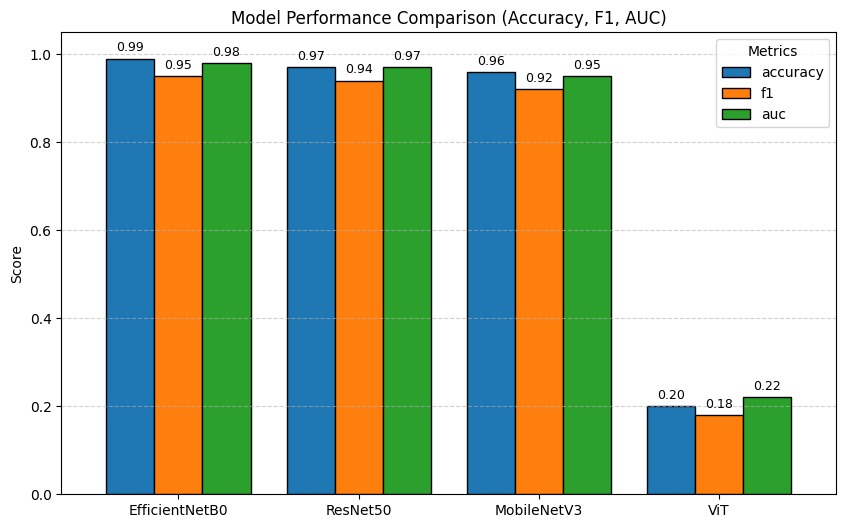

In [102]:
results = {
    "ResNet50": {"accuracy": 0.97, "f1": 0.94, "auc": 0.97},
    "MobileNetV3": {"accuracy": 0.96, "f1": 0.92, "auc": 0.95},
    "EfficientNetB0": {"accuracy": 0.99, "f1": 0.95, "auc": 0.98},
    "ViT": {"accuracy": 0.20, "f1": 0.18, "auc": 0.22}
}
df = pd.DataFrame(results).T
metrics = ["accuracy", "f1", "auc"]
df_metrics = df[metrics]
df_metrics = df_metrics.sort_values(by="accuracy", ascending=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
ax = df_metrics.plot(kind="bar", figsize=(10,6), width=0.8, color=colors, edgecolor='black')
plt.title("Model Performance Comparison (Accuracy, F1, AUC)")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Metrics")
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height + 0.01),
                    ha='center', va='bottom', fontsize=9)

plt.show()

**Get last convolutional layer**

In [103]:
target_layer = None
for name, layer in reversed(list(model.named_modules())):
    if isinstance(layer, torch.nn.Conv2d):
        target_layer = layer
        break
if target_layer is None:
    raise Exception("No convolutional layer found in the model.")


**Register hooks**

In [104]:
activations = []
gradients = []
def forward_hook(module, input, output):
    activations.append(output.detach())
def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0].detach())
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)


**Load image**

In [105]:
image = Image.open(img_path).convert("RGB")
image_resized = image.resize((224, 224))

**Forward pass**

In [106]:
input_tensor = transform(image).unsqueeze(0).to(device)
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

**Backward pass**

In [107]:
model.zero_grad()
output[0, pred_class].backward()

**Grad--Cam**

In [108]:
grad = gradients[0]
fmap = activations[0]
weights = torch.mean(grad, dim=(2, 3), keepdim=True)
cam = torch.sum(weights * fmap, dim=1).squeeze()
cam = F.relu(cam)
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)
cam = cam.cpu().numpy()
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
image_np = np.array(image_resized)
heatmap = cv2.resize(heatmap, (image_np.shape[1], image_np.shape[0]))
overlay = (0.5 * image_np + 0.5 * heatmap).astype(np.uint8)


Image 1
Path: dataset/val/FU-athlete-foot/FU-athlete-foot (56).jpg
Actual class: FU-athlete-foot


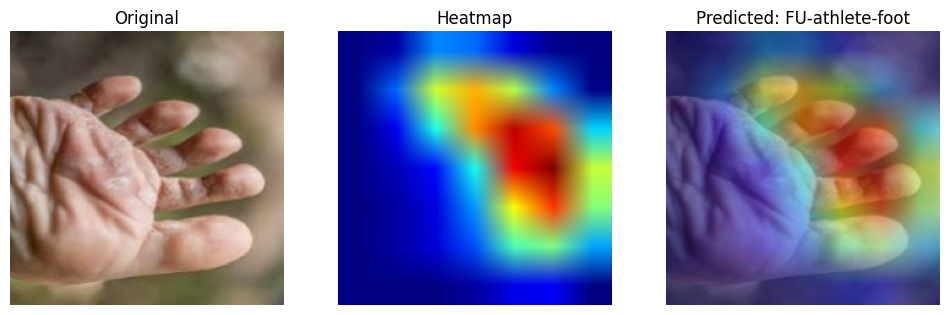


Image 2
Path: dataset/val/VI-chickenpox/50_VI-chickenpox (24).jpg
Actual class: VI-chickenpox


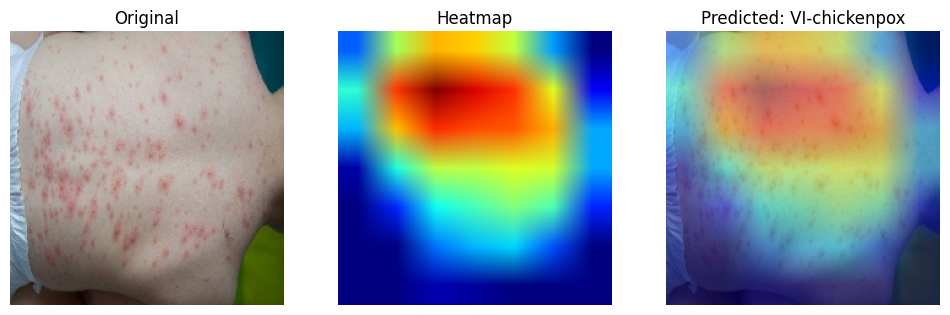

In [109]:
for i in range(2):
    img_path, label = random.choice(val.samples)
    print(f"\nImage {i+1}")
    print("Path:", img_path)
    print("Actual class:", classes[label])
    generate_gradcam(img_path)